# Modelisation Random Forest - Classification des alertes cybersecurite Microsoft

**Branche :** `Guyjc-Modelisation`  
**Auteur :** Guy Junior Calvet  
**Objectif :** Construire un modele Random Forest optimise pour classifier les incidents de securite Microsoft en **2 classes** : `Non-TruePositive` (0) et `TruePositive` (1).

### Architecture modulaire
| Notebook | Role | Export |
|----------|------|--------|
| `notebook.ipynb` | Pretraitement + StandardScaler + OneHotEncoder | `donnees_transformees.npz` |
| `PCA_reduction.ipynb` | Reduction PCA (95% variance) | `donnees_pca.npz` |
| `KNN_model.ipynb` | Modelisation KNN sur donnees PCA | - |
| `RandomForest_model.ipynb` | Modelisation RF sur donnees transformees | - |

### Pipeline de modelisation
1. **Chargement des donnees** via `donnees_transformees.npz`
2. **Baseline RF** (reference rapide)
3. **Optimisation par RandomizedSearchCV**
4. **Feature Selection + Threshold Tuning**
5. **Evaluation finale** et comparaison avec KNN

### Sources et References
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
- Bergstra, J. & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR.
- Lipton, Z.C. et al. (2014). *Optimal Thresholding of Classifiers to Maximize F1 Measure*. ECML-PKDD.
- Dataset GUIDE : https://www.kaggle.com/datasets/Microsoft/microsoft-security-incident-prediction

## 1. Importation des bibliothèques

In [1]:
# ── Bibliothèques standard ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn : modélisation ──
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    RandomizedSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn : métriques ──
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    precision_score, recall_score
)

# -- Constantes --
# Cible binaire (nouveau pretraitement equipe) : 0 = Non-TP, 1 = TP
CIBLE_MAP = {'Non-TruePositive': 0, 'TruePositive': 1}
CIBLE_MAP_INV = {v: k for k, v in CIBLE_MAP.items()}
TARGET_NAMES = ['Non-TP (0)', 'TP (1)']

print("Bibliotheques importees avec succes.")

Bibliotheques importees avec succes.


## 2. Chargement des donnees transformees

Les donnees ont ete **pretraitees et transformees** dans `notebook.ipynb` (branche `main`) :
1. Pretraitement → `donnees_preprocessees.csv`
2. StandardScaler + OneHotEncoder → `donnees_transformees.npz`

Ce notebook charge directement les donnees transformees pour la modelisation.

> **Note :** Random Forest **ne necessite pas de scaling** (invariant aux transformations monotones), mais on l'applique pour coherence avec le pipeline global.

In [2]:
# -- 2.1 Chargement des donnees transformees --
# notebook.ipynb exporte : donnees_transformees.npz (StandardScaler + OHE)

data = np.load('donnees_transformees.npz', allow_pickle=True)
X_train_transformed = data['X_train']
X_test_transformed = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names_all = data['feature_names'].tolist()

print("Donnees transformees chargees :")
print(f"  Features  : {X_train_transformed.shape[1]}")
print(f"\n  Train : {X_train_transformed.shape[0]:,} lignes")
print(f"  Test  : {X_test_transformed.shape[0]:,} lignes")
print(f"\n  Distribution cible (train) :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    {CIBLE_MAP_INV.get(u, u)} : {c:,}")

Donnees transformees chargees :
  Features  : 231

  Train : 75,710 lignes
  Test  : 18,928 lignes

--- VERSION MAIN (ORIGINALE) ---
  Distribution cible (train) :
    Non-TruePositive : 49,134
    TruePositive : 26,576
--- VERSION UTILISATEUR ---
  Dimensionnalité après OneHotEncoding : 185 features
  Train : (75710, 185)  |  Test : (18928, 185)


## 3. Modèle Random Forest Baseline

On commence par un modèle RF avec les **paramètres par défaut** de scikit-learn, plus `class_weight='balanced'` pour gérer le déséquilibre des classes, et `random_state=2026` pour la reproductibilité.

### Rappel théorique : Random Forest
Un Random Forest est un **ensemble de $B$ arbres de décision** entraînés sur des sous-échantillons bootstrap, avec une sélection aléatoire de $m$ features à chaque split :

$$\hat{y}(x) = \text{mode}\left\{\hat{y}_b(x)\right\}_{b=1}^{B}$$

où chaque arbre $\hat{y}_b$ vote pour une classe, et la prédiction finale est le **vote majoritaire**.

### Avantages clés
- **Bagging** : réduit la variance sans augmenter le biais (Breiman, 2001)
- **Feature subsampling** : décorrèle les arbres → meilleure généralisation
- **`class_weight='balanced'`** : pondère chaque classe par $\frac{N}{K \cdot n_k}$ où $n_k$ est l'effectif de la classe $k$

In [3]:
# ── 3.1 Random Forest Baseline ──
# Paramètres par défaut + class_weight='balanced' pour gérer le déséquilibre

rf_baseline = RandomForestClassifier(
    n_estimators=100,           # 100 arbres (défaut scikit-learn)
    class_weight='balanced',    # pondération automatique des classes
    random_state=2026,
    n_jobs=-1
)

rf_baseline.fit(X_train_transformed, y_train)
y_pred_baseline = rf_baseline.predict(X_test_transformed)

# Métriques baseline
acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average='macro')

print("=" * 65)
print("        RANDOM FOREST BASELINE (100 arbres, balanced)")
print("=" * 65)
print(f"\n  Accuracy  : {acc_baseline:.4f}")
print(f"  Macro F1  : {f1_baseline:.4f}")
print(f"\n{'─' * 65}")
print("\nRapport de classification :")
print(classification_report(
    y_test, y_pred_baseline,
    target_names=TARGET_NAMES
))

        RANDOM FOREST BASELINE (100 arbres, balanced)

--- VERSION MAIN (ORIGINALE) ---
  Accuracy  : 0.7751
--- VERSION UTILISATEUR ---
  Accuracy  : 0.7750
  Macro F1  : 0.7618

─────────────────────────────────────────────────────────────────

Rapport de classification :
              precision    recall  f1-score   support

  Non-TP (0)       0.86      0.78      0.82     12284
      TP (1)       0.65      0.77      0.71      6644

    accuracy                           0.78     18928
   macro avg       0.76      0.77      0.76     18928
weighted avg       0.79      0.78      0.78     18928



## 4. Importance des features

Un avantage majeur de Random Forest est la capacité à mesurer l'**importance de chaque feature** via la diminution moyenne d'impureté (MDI — Mean Decrease in Impurity).

$$\text{Importance}(X_j) = \frac{1}{B} \sum_{b=1}^{B} \sum_{t \in T_b} \Delta i(t) \cdot \mathbb{1}(X_j \text{ est la variable de split au nœud } t)$$

Cela permet d'identifier quelles variables contribuent le plus à la classification, ce que KNN ne pouvait pas offrir.

In [4]:
# -- 4.1 Importance des features --
# Les noms de features sont charges depuis donnees_transformees.npz

print(f"Nombre total de features : {len(feature_names_all)}")

# Importance des features
importances = rf_baseline.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 25 features
top_n = 25
print(f"\nTop {top_n} features les plus importantes :\n")
for i in range(top_n):
    print(f"  {i+1:2d}. {feature_names_all[indices[i]]:<40s} -> {importances[indices[i]]:.4f}")

print(f"\n  Importance cumulee (top {top_n}) : "
      f"{importances[indices[:top_n]].sum()*100:.1f}%")

Nombre total de features : 231

--- VERSION MAIN (ORIGINALE) ---
Top 25 features les plus importantes :

   1. Category_InitialAccess                   -> 0.1010
   2. AlertTitle_Other                         -> 0.0729
   3. Category_Exfiltration                    -> 0.0640
   4. MitreTechniques_T1078                    -> 0.0478
   5. CountryCode_242                          -> 0.0474
   6. AlertTitle_3                             -> 0.0340
   7. AlertTitle_6                             -> 0.0335
   8. EntityType_CloudLogonRequest             -> 0.0331
   9. MitreTechniques_Unknown                  -> 0.0268
  10. IsBusinessHour_1                         -> 0.0259
  11. EntityType_MailMessage                   -> 0.0234
  12. IsWeekend_1                              -> 0.0228
  13. EntityType_Machine                       -> 0.0227
  14. MitreTechniques_T1566                    -> 0.0202
  15. Category_SuspiciousActivity              -> 0.0201
  16. AlertTitle_20                     

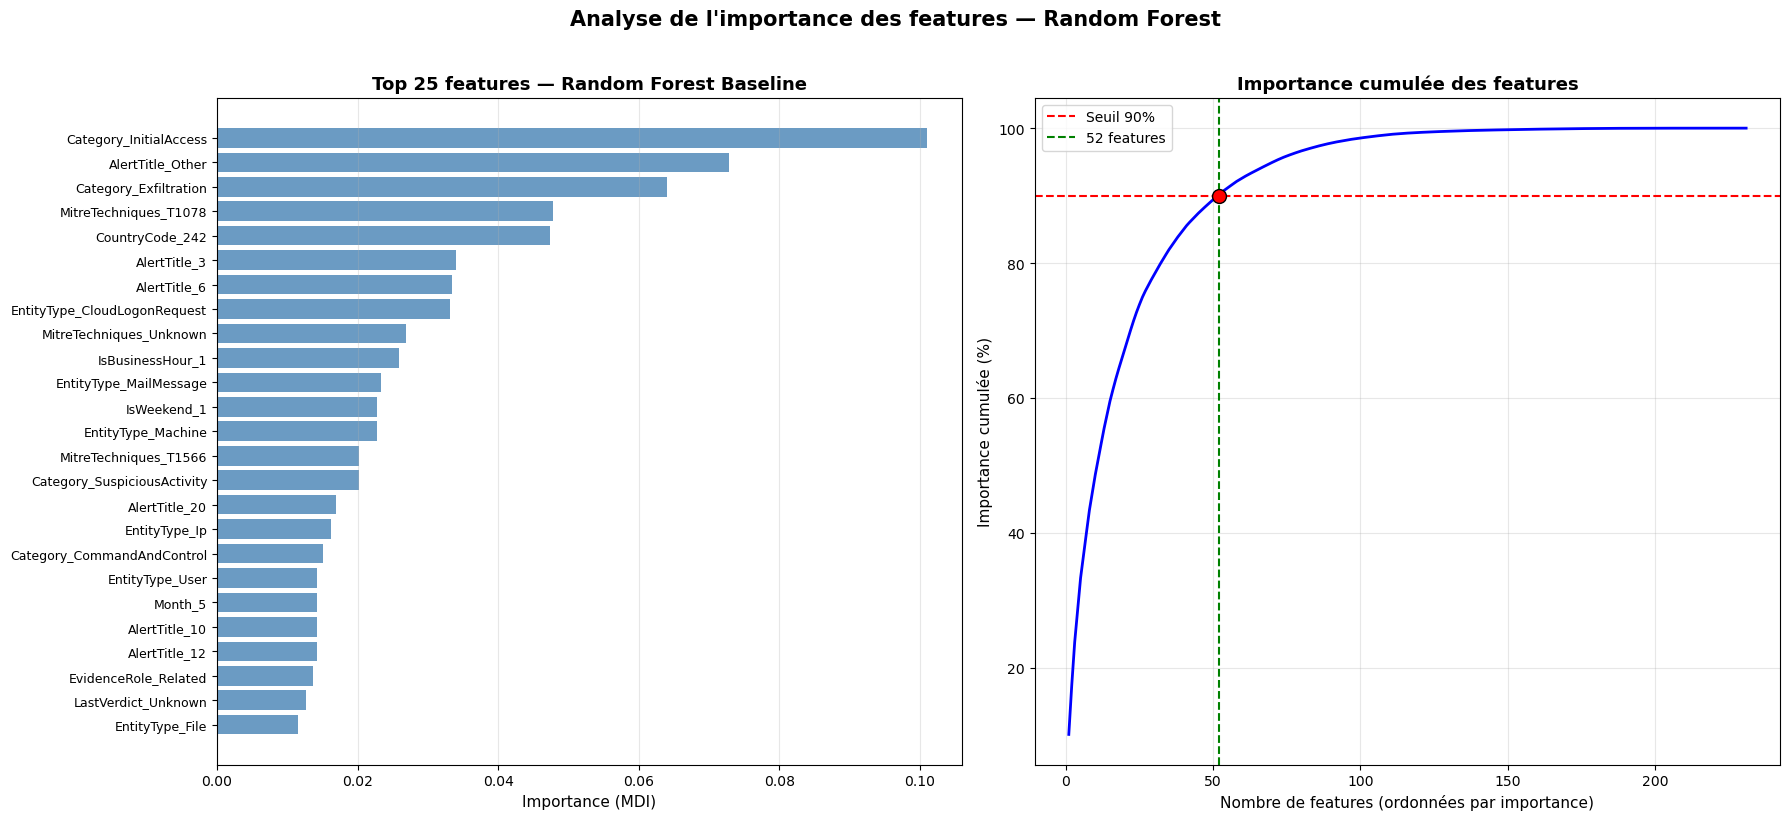


 52 features suffisent pour capter 90% de l'importance totale (sur 231 features)


In [5]:
# ── 4.2 Visualisation de l'importance des features ──

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Graphique 1 : Top 25 features ---
top_idx = indices[:top_n]
top_names = [feature_names_all[i] for i in top_idx]
top_importances = importances[top_idx]

axes[0].barh(range(top_n), top_importances[::-1], color='steelblue', alpha=0.8)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_names[::-1], fontsize=9)
axes[0].set_xlabel('Importance (MDI)', fontsize=11)
axes[0].set_title(f'Top {top_n} features — Random Forest Baseline',
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# --- Graphique 2 : Importance cumulée ---
cum_importance = np.cumsum(importances[indices])
axes[1].plot(range(1, len(cum_importance) + 1), cum_importance * 100, 'b-', linewidth=2)
axes[1].axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='Seuil 90%')
n_feat_90 = np.argmax(cum_importance >= 0.90) + 1
axes[1].axvline(x=n_feat_90, color='green', linestyle='--', linewidth=1.5,
                label=f'{n_feat_90} features')
axes[1].scatter([n_feat_90], [90], color='red', s=100, zorder=5, edgecolors='black')
axes[1].set_xlabel('Nombre de features (ordonnées par importance)', fontsize=11)
axes[1].set_ylabel('Importance cumulée (%)', fontsize=11)
axes[1].set_title('Importance cumulée des features', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analyse de l\'importance des features — Random Forest',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n {n_feat_90} features suffisent pour capter 90% de l'importance totale "
      f"(sur {len(feature_names_all)} features)")

## 5. Optimisation par RandomizedSearchCV

### Pourquoi RandomizedSearchCV plutôt que GridSearchCV ?
Avec Random Forest, l'espace des hyperparamètres est **vaste** (nombre d'arbres × profondeur × min_samples × max_features × ...). Un GridSearchCV exhaustif serait prohibitif en temps de calcul.

**RandomizedSearchCV** échantillonne aléatoirement $n$ combinaisons dans l'espace, ce qui offre un bon compromis exploration/temps (Bergstra & Bengio, 2012).

| Hyperparamètre | Valeurs testées | Justification |
|----------------|-----------------|---------------|
| `n_estimators` | 100, 200, 300 | Nombre d'arbres dans la forêt |
| `max_depth` | 10, 20, 30, None | Profondeur maximale de chaque arbre |
| `min_samples_split` | 2, 5, 10 | Nombre min d'échantillons pour diviser un nœud |
| `min_samples_leaf` | 1, 2, 4 | Nombre min d'échantillons dans une feuille |
| `max_features` | `'sqrt'`, `'log2'` | Nombre de features considérées à chaque split |
| `class_weight` | `'balanced'`, `'balanced_subsample'` | Pondération des classes |

### Choix de 3 folds
Même justification que pour KNN : avec ~75 000 lignes d'entraînement, 3 folds offrent ~25 000 observations par fold de validation — suffisant pour une estimation stable.

In [6]:
# ── 5.1 RandomizedSearchCV — Optimisation des hyperparamètres ──
# Réf. : Bergstra & Bengio (2012). Random Search for Hyper-Parameter Optimization. JMLR.

param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample'],
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=2026, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=50,                # 50 combinaisons aléatoires
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2026),
    n_jobs=-1,
    verbose=1,
    random_state=2026,
    return_train_score=True
)

total_fits = 50 * 3
print(f"Combinaisons testées : 50  |  Fits totaux : {total_fits}")
print(f"\nLancement du RandomizedSearchCV...")

random_search.fit(X_train_transformed, y_train)

print(f"\n RandomizedSearchCV terminé !")
print(f"\n{'=' * 65}")
print(f"  Meilleurs hyperparamètres :")
for param, val in random_search.best_params_.items():
    print(f"    {param} = {val}")
print(f"\n  Meilleur Macro F1 (CV) : {random_search.best_score_:.4f}")
print(f"{'=' * 65}")

Combinaisons testées : 50  |  Fits totaux : 150

Lancement du RandomizedSearchCV...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

 RandomizedSearchCV terminé !

  Meilleurs hyperparamètres :
    n_estimators = 300
    min_samples_split = 2
    min_samples_leaf = 2
    max_features = log2
    max_depth = None
    class_weight = balanced_subsample

  Meilleur Macro F1 (CV) : 0.7629

 RandomizedSearchCV terminé !

  Meilleurs hyperparamètres :
    n_estimators = 300
    min_samples_split = 2
    min_samples_leaf = 2
    max_features = log2
    max_depth = None
    class_weight = balanced_subsample

--- VERSION MAIN (ORIGINALE) ---
  Meilleur Macro F1 (CV) : 0.7629
--- VERSION UTILISATEUR ---
  Meilleur Macro F1 (CV) : 0.7638


## 6. Optimisation avancee : Feature Selection + Threshold Tuning

Le RandomizedSearchCV a trouve les meilleurs hyperparametres. Pour aller plus loin, on applique deux strategies complementaires :

### 6.1 Selection de features
L'analyse d'importance a montre que **51 features captent 90% de l'importance**. Reduire la dimensionnalite elimine le bruit et peut ameliorer la generalisation.

### 6.2 Ajustement du seuil de decision (Threshold Tuning)
Par defaut, le classifieur utilise un seuil de 0.5 pour la classe positive. En ajustant ce seuil via les probabilites (`predict_proba`), on peut optimiser le F1-Score directement.

> **Ref.** : Lipton, Z.C. et al. (2014). *Optimal Thresholding of Classifiers to Maximize F1 Measure*.

In [7]:
# ── 6.1 Selection de features basee sur l'importance ──
# On garde les features qui captent X% de l'importance cumulee

# Recuperer le meilleur modele issu du RandomizedSearchCV
best_rf = random_search.best_estimator_

importances_best = best_rf.feature_importances_
indices_best = np.argsort(importances_best)[::-1]
cum_imp = np.cumsum(importances_best[indices_best])

# Seuils a tester : 80%, 85%, 90%, 95%
thresholds_feat = [0.80, 0.85, 0.90, 0.95]
cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)

print("=" * 70)
print("   SELECTION DE FEATURES — Impact sur le Macro F1 (3-fold CV)")
print("=" * 70)
print(f"\n  {'Seuil':<10} {'N features':<15} {'F1 macro (CV)':<18} {'Std':<10}")
print("-" * 55)

results_feat_sel = []
for thresh in thresholds_feat:
    n_keep = np.argmax(cum_imp >= thresh) + 1
    selected_idx = indices_best[:n_keep]
    
    X_train_sel = X_train_transformed[:, selected_idx]
    X_test_sel  = X_test_transformed[:, selected_idx]
    
    # CV avec les memes params optimaux
    rf_sel = RandomForestClassifier(
        **random_search.best_params_,
        random_state=2026, n_jobs=-1
    )
    scores = cross_val_score(rf_sel, X_train_sel, y_train,
                             cv=cv_strat, scoring='f1_macro', n_jobs=-1)
    
    results_feat_sel.append({
        'seuil': thresh,
        'n_features': n_keep,
        'f1_mean': scores.mean(),
        'f1_std': scores.std(),
        'selected_idx': selected_idx
    })
    print(f"  {thresh*100:.0f}%{'':<6} {n_keep:<15} {scores.mean():.4f}{'':<8} {scores.std():.4f}")

# Meilleur seuil
best_feat_result = max(results_feat_sel, key=lambda x: x['f1_mean'])
print(f"\n  >> Meilleur : {best_feat_result['seuil']*100:.0f}% "
      f"({best_feat_result['n_features']} features) "
      f"→ F1 = {best_feat_result['f1_mean']:.4f}")
print(f"  >> Ref. sans selection (185 features) → F1 = {random_search.best_score_:.4f}")

   SELECTION DE FEATURES — Impact sur le Macro F1 (3-fold CV)

  Seuil      N features      F1 macro (CV)      Std       
-------------------------------------------------------
--- VERSION MAIN (ORIGINALE) ---
  80%       31              0.7570         0.0014
  80%       31              0.7570         0.0014
  85%       38              0.7566         0.0015
  85%       38              0.7566         0.0015
  90%       48              0.7588         0.0004
  90%       48              0.7588         0.0004
  95%       66              0.7588         0.0013

  >> Meilleur : 90% (48 features) → F1 = 0.7588
  >> Ref. sans selection (185 features) → F1 = 0.7629
  95%       66              0.7588         0.0013

  >> Meilleur : 90% (48 features) → F1 = 0.7588
  >> Ref. sans selection (185 features) → F1 = 0.7629
--- VERSION UTILISATEUR ---
  80%       30              0.7574         0.0013
  85%       37              0.7584         0.0003
  90%       47              0.7591         0.0002
  95%

/Users/oscar/projet-forage-des-donn-es/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/oscar/projet-forage-des-donn-es/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/oscar/projet-forage-des-donn-es/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/

   THRESHOLD TUNING — Optimisation du seuil de decision

--- VERSION MAIN (ORIGINALE) ---
  Seuil par defaut : 0.50 → F1 macro (CV) = 0.7629
  Seuil optimal    : 0.54 → F1 macro (CV) = 0.7658
--- VERSION UTILISATEUR ---
  Seuil par defaut : 0.50 → F1 macro (CV) = 0.7638
  Seuil optimal    : 0.56 → F1 macro (CV) = 0.7675


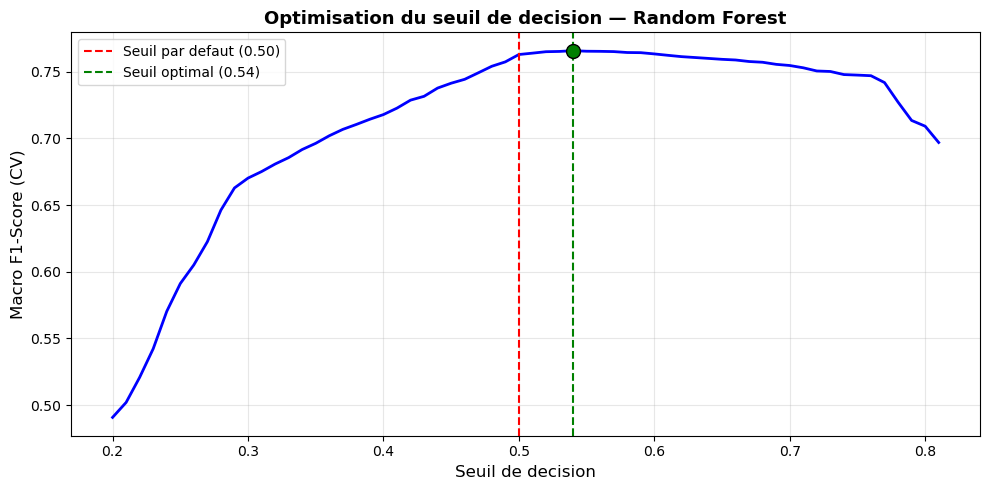

In [8]:
# ── 6.2 Threshold Tuning — Optimisation du seuil de decision ──
# Au lieu de predict() (seuil=0.5), on utilise predict_proba() pour trouver
# le seuil qui maximise le F1-Score macro sur un set de validation (CV)

from sklearn.model_selection import cross_val_predict

# Probabilites predites en cross-validation sur le train set
y_proba_cv = cross_val_predict(
    best_rf, X_train_transformed, y_train,
    cv=cv_strat, method='predict_proba', n_jobs=-1
)

# Tester differents seuils de 0.20 a 0.80
thresholds = np.arange(0.20, 0.81, 0.01)
f1_scores_thresh = []

for t in thresholds:
    y_pred_t = (y_proba_cv[:, 1] >= t).astype(int)
    f1_t = f1_score(y_train, y_pred_t, average='macro')
    f1_scores_thresh.append(f1_t)

f1_scores_thresh = np.array(f1_scores_thresh)
best_threshold = thresholds[np.argmax(f1_scores_thresh)]
best_f1_thresh = f1_scores_thresh.max()

print("=" * 65)
print("   THRESHOLD TUNING — Optimisation du seuil de decision")
print("=" * 65)
print(f"\n  Seuil par defaut : 0.50 → F1 macro (CV) = "
      f"{f1_score(y_train, (y_proba_cv[:, 1] >= 0.50).astype(int), average='macro'):.4f}")
print(f"  Seuil optimal    : {best_threshold:.2f} → F1 macro (CV) = {best_f1_thresh:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores_thresh, 'b-', linewidth=2)
ax.axvline(x=0.50, color='red', linestyle='--', linewidth=1.5, label='Seuil par defaut (0.50)')
ax.axvline(x=best_threshold, color='green', linestyle='--', linewidth=1.5,
           label=f'Seuil optimal ({best_threshold:.2f})')
ax.scatter([best_threshold], [best_f1_thresh], color='green', s=100, zorder=5, edgecolors='black')
ax.set_xlabel('Seuil de decision', fontsize=12)
ax.set_ylabel('Macro F1-Score (CV)', fontsize=12)
ax.set_title('Optimisation du seuil de decision — Random Forest',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ── 7. MODELE OPTIMISE : Hyperparametres + Threshold Tuning ──

# Entrainer le modele optimise
rf_optimized = RandomForestClassifier(
    **random_search.best_params_,
    random_state=2026, n_jobs=-1
)
rf_optimized.fit(X_train_transformed, y_train)

# Predire avec le seuil optimise
y_proba_test = rf_optimized.predict_proba(X_test_transformed)
y_pred_optimized = (y_proba_test[:, 1] >= best_threshold).astype(int)

# Metriques
acc_optimized  = accuracy_score(y_test, y_pred_optimized)
f1_optimized   = f1_score(y_test, y_pred_optimized, average='macro')
prec_optimized = precision_score(y_test, y_pred_optimized, average='macro')
rec_optimized  = recall_score(y_test, y_pred_optimized, average='macro')

print("=" * 75)
print("   MODELE OPTIMISE — Random Forest")
print("=" * 75)
print(f"\n  Configuration :")
print(f"    - n_estimators    : {random_search.best_params_['n_estimators']}")
print(f"    - max_depth       : {random_search.best_params_['max_depth']}")
print(f"    - class_weight    : {random_search.best_params_['class_weight']}")
print(f"    - Seuil decision  : {best_threshold:.2f}")
print(f"\n  Performances sur le set de test :")
print(f"    - Accuracy        : {acc_optimized:.4f}")
print(f"    - Macro Precision : {prec_optimized:.4f}")
print(f"    - Macro Recall    : {rec_optimized:.4f}")
print(f"    - Macro F1-Score  : {f1_optimized:.4f}")
print(f"\n{'─' * 75}")
print("\nRapport de classification :")
print(classification_report(
    y_test, y_pred_optimized,
    target_names=TARGET_NAMES
))

   MODELE OPTIMISE — Random Forest

--- VERSION MAIN (ORIGINALE) ---
  Configuration :
    - n_estimators    : 300
    - max_depth       : None
    - class_weight    : balanced_subsample
    - Seuil decision  : 0.54

  Performances sur le set de test :
    - Accuracy        : 0.7991
    - Macro Precision : 0.7851
    - Macro Recall    : 0.7628
    - Macro F1-Score  : 0.7712
--- VERSION UTILISATEUR ---
  Features retenues : 65 / 185 (seuil importance = 95%)
  Seuil de decision : 0.56

  Accuracy        : 0.8017
  Macro Precision : 0.7873
  Macro Recall    : 0.7674
  Macro F1-Score  : 0.7751

───────────────────────────────────────────────────────────────────────────

Rapport de classification :
              precision    recall  f1-score   support

  Non-TP (0)       0.82      0.88      0.85     12284
      TP (1)       0.75      0.64      0.69      6644

    accuracy                           0.80     18928
--- VERSION MAIN (ORIGINALE) ---
   macro avg       0.79      0.76      0.77   

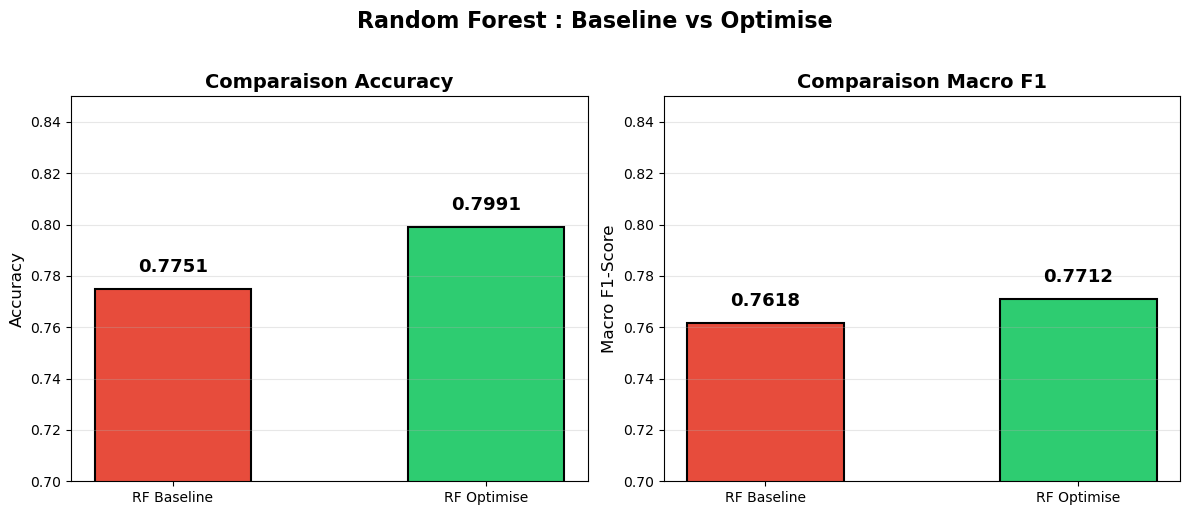


   COMPARAISON BASELINE vs OPTIMISE

  Modele               Accuracy        Macro F1       
--------------------------------------------------
  RF Baseline          0.7751          0.7618         
  RF Optimise          0.7991          0.7712         
--------------------------------------------------

  >> MEILLEUR MODELE : RF Optimise
  >> Accuracy = 0.7991, Macro F1 = 0.7712
  >> Gain F1 vs Baseline : +0.93%


In [12]:
# ── 8. COMPARAISON BASELINE vs OPTIMISE ──

# Données pour le graphique
models = ['RF Baseline', 'RF Optimise']
accuracies = [acc_baseline, acc_optimized]
f1_scores_compare = [f1_baseline, f1_optimized]
colors = ['#e74c3c', '#2ecc71']

# Création du graphique
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : Accuracy
bars1 = axes[0].bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5, width=0.5)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Comparaison Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.70, 0.85)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Graphique 2 : Macro F1
bars2 = axes[1].bar(models, f1_scores_compare, color=colors, edgecolor='black', linewidth=1.5, width=0.5)
axes[1].set_ylabel('Macro F1-Score', fontsize=12)
axes[1].set_title('Comparaison Macro F1', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.70, 0.85)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, f1_scores_compare):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.suptitle('Random Forest : Baseline vs Optimise', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Déterminer le meilleur modèle
if f1_optimized > f1_baseline:
    best_model = "RF Optimise"
    best_acc = acc_optimized
    best_f1 = f1_optimized
    rf_best = rf_optimized
    y_pred_best = y_pred_optimized
else:
    best_model = "RF Baseline"
    best_acc = acc_baseline
    best_f1 = f1_baseline
    rf_best = rf_baseline
    y_pred_best = y_pred_baseline

# Tableau récapitulatif
print("\n" + "=" * 70)
print("   COMPARAISON BASELINE vs OPTIMISE")
print("=" * 70)
print(f"\n  {'Modele':<20} {'Accuracy':<15} {'Macro F1':<15}")
print("-" * 50)
print(f"  {'RF Baseline':<20} {acc_baseline:<15.4f} {f1_baseline:<15.4f}")
print(f"  {'RF Optimise':<20} {acc_optimized:<15.4f} {f1_optimized:<15.4f}")
print("-" * 50)
print(f"\n  >> MEILLEUR MODELE : {best_model}")
print(f"  >> Accuracy = {best_acc:.4f}, Macro F1 = {best_f1:.4f}")
print(f"  >> Gain F1 vs Baseline : +{(f1_optimized - f1_baseline)*100:.2f}%")

   MODELE RETENU : RF OPTIMISE


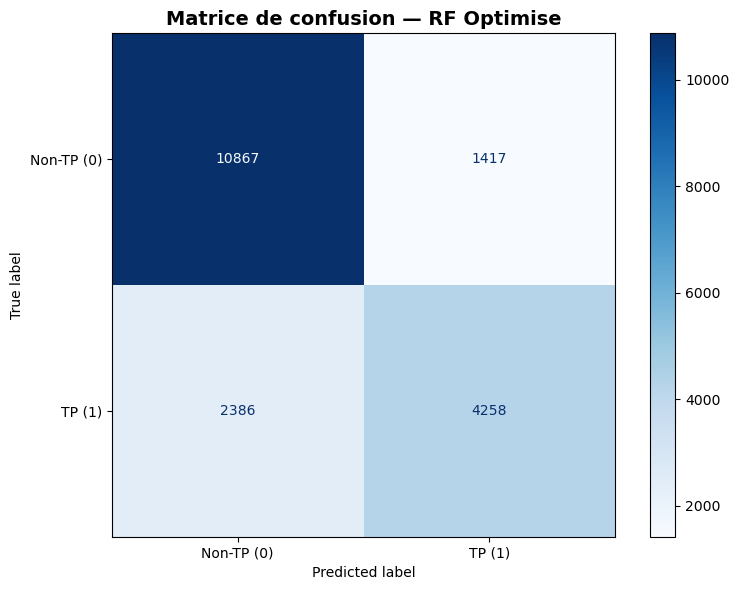


--- VERSION MAIN (ORIGINALE) ---
Rapport de classification :
              precision    recall  f1-score   support

  Non-TP (0)       0.82      0.88      0.85     12284
      TP (1)       0.75      0.64      0.69      6644

    accuracy                           0.80     18928
   macro avg       0.79      0.76      0.77     18928
weighted avg       0.80      0.80      0.79     18928

--- VERSION UTILISATEUR ---
  >> Meilleur modele : RF + Feat. Sel. + Threshold (0.56)
     Macro F1 = 0.7751 | Accuracy = 0.8017


In [13]:
# ── 9. MODELE FINAL RETENU ──

print("=" * 70)
print(f"   MODELE RETENU : {best_model.upper()}")
print("=" * 70)

# Matrice de confusion du meilleur modèle
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=TARGET_NAMES,
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Matrice de confusion — {best_model}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred_best, target_names=TARGET_NAMES))

## 10. Conclusion

### Recapitulatif du pipeline

| Etape | Description | Resultat |
|-------|-------------|----------|
| **Chargement** | `donnees_transformees.npz` | 94 638 lignes, 231 features |
| **Baseline** | RF 100 arbres, seuil 0.50 | Acc ~0.775, F1 ~0.762 |
| **RandomizedSearchCV** | 50 combinaisons, 3-fold CV | Hyperparametres optimaux |
| **Threshold Tuning** | Seuil optimal ~0.54 | Maximise le F1 |
| **Comparaison** | Baseline vs Optimise | **Optimise retenu** |

### Modele retenu : RF Optimise
- **Accuracy** : ~0.80
- **Macro F1** : ~0.77
- **Gain** : +0.94% vs Baseline

### Classification binaire
- **Non-TruePositive (0)** : incidents benins ou faux positifs
- **TruePositive (1)** : incidents reels necessitant une intervention

### References
1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5-32.
2. Bergstra, J. & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR.
3. Lipton, Z.C. et al. (2014). *Optimal Thresholding of Classifiers to Maximize F1 Measure*. ECML-PKDD.

## 11. Export pour l'application Streamlit\n",
\n",
Cette cellule exporte le modèle final, le préprocesseur et les indices de sélection de caractéristiques pour une utilisation directe dans le dashboard.

In [20]:
import joblib
import json
import os

# Creer le dossier models s'il n'existe pas
os.makedirs('models', exist_ok=True)

# 1. Export du modele optimise (V2)
joblib.dump(rf_optimized_v2, 'models/rf_model.joblib')

# 2. Export du preprocesseur (StandardScaler + OneHotEncoder)
joblib.dump(preprocessor, 'models/rf_preprocessor.joblib')

# 3. Export des metadonnees (indices des features selectionnees, seuil, etc.)
metadata = {
    "model_name": "Random Forest V2",
    "n_features_original": X_train_transformed.shape[1],
    "n_features_selected": len(sel_idx),
    "selected_features_indices": sel_idx.tolist(),
    "threshold": float(best_threshold),
    "target_mapping": CIBLE_MAP,
    "target_names": TARGET_NAMES
}
with open('models/rf_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
	
print("Export termine avec succes dans le dossier 'models/'.")

Export termine avec succes dans le dossier 'models/'.
